In [1]:
import os
from dataset import load_dataset
import joblib
from regression.RandomForest.random_forest_regression import RandomForestRegressorModel
from regression.probabilistic_rf_scoring import fit_rank_pdfs_loglik
from regression.probabilistic_rf_scoring import plot_ranked_pdfs
from regression.probabilistic_rf_scoring import plot_pdf_with_true_target
from sklearn.inspection import PartialDependenceDisplay
from sklearn.inspection import permutation_importance
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
plt.style.use("default")
from plot_style import set_plot_style
set_plot_style()

In [2]:
TARGET_COL = "trq_target"
FEATURES=["trq_measured","mgt","ias","oat","np_ng_ratio","pa"]
TRAIN_PATH_SPLIT= "../../../../data/processed/split_85_15/train_85.csv"
TEST_PATH_SPLIT= "../../../../data/processed/split_85_15/test_15.csv"
OUTPUT_PATH= "../../../../output/random_forest_regressor/model_target/"
MODEL_PATH="random_forest_model_target.pkl"
METRIC_TRAIN="metric_train.csv"
METRIC_TEST="metric_test.csv"

In [3]:
train_df = load_dataset(TRAIN_PATH_SPLIT)
test_df = load_dataset(TEST_PATH_SPLIT)

X_train = train_df[FEATURES].values
y_train = train_df[TARGET_COL].values

X_test = test_df[FEATURES].values
y_test = test_df[TARGET_COL].values

In [4]:
rf_model = RandomForestRegressorModel(
    n_estimators=500,
    min_samples_leaf=3,
)

if os.path.exists(OUTPUT_PATH+MODEL_PATH):
    rf_model=joblib.load(OUTPUT_PATH+MODEL_PATH)
else:
    rf_model.fit(X_train, y_train)
    joblib.dump(rf_model, OUTPUT_PATH + MODEL_PATH)

In [5]:
metric_train=rf_model.evaluate(X_train, y_train,"train")
df_metric_train = pd.DataFrame([metric_train])
df_metric_train.to_csv(OUTPUT_PATH+METRIC_TRAIN, index=False)

metric_validate=rf_model.evaluate(X_test, y_test,"test")
df_metric_test = pd.DataFrame([metric_validate])
df_metric_test.to_csv(OUTPUT_PATH+METRIC_TEST, index=False)


Metrics on train
MAE  : 0.077253
RMSE : 0.139105
R²   : 0.999903

Metrics on test
MAE  : 0.126155
RMSE : 0.218526
R²   : 0.999764


In [6]:
id=1000
test_row=test_df.iloc[id]
torque_measured=test_row['trq_measured']
torque_margin_true=test_row['trq_margin']
testX = test_df.loc[[id], FEATURES].to_numpy()
tree_preds = rf_model.predict_trees(testX)
tree_preds["trq_margin_pred"] = (torque_measured / tree_preds["trq_target_prediction"] - 1) * 100
tree_preds.head()

,trq_target_prediction,trq_margin_pred
0,54.551207,-2.293638
1,55.588247,-4.116423
2,55.121115,-3.303843
3,55.901063,-4.652975
4,55.286968,-3.593917


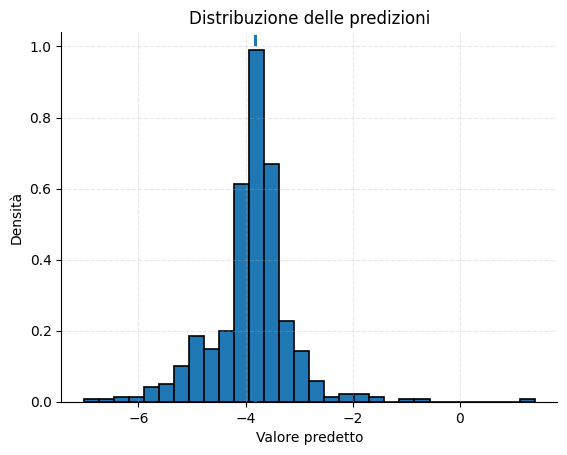

In [7]:
plt.figure()
plt.hist(tree_preds["trq_margin_pred"], bins=30, density=True)
plt.axvline(np.median(tree_preds["trq_margin_pred"]), linestyle="--", label="Predizione puntuale")
plt.xlabel("Valore predetto")
plt.xlabel("Valore predetto")
plt.ylabel("Densità")
plt.title("Distribuzione delle predizioni")
plt.show()

In [8]:
from regression.probabilistic_rf_scoring import fit_best_pdf

best,results= fit_best_pdf(tree_preds["trq_margin_pred"])

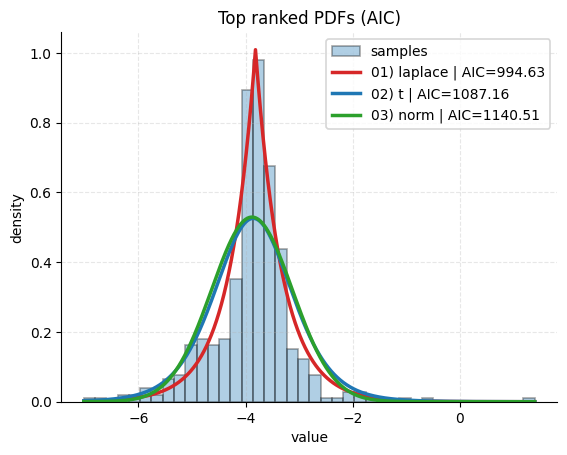

[{'pdf_type': 'laplace', 'fit_ok': True, 'pdf_args': {'args': (), 'loc': -3.8157197474184725, 'scale': 0.49533786509890704}, 'loglik': -495.3159935333147, 'aic': 994.6319870666294, 'bic': 1003.0612032634739, 'k': 2, 'n': 500, 'error': ''}, {'pdf_type': 't', 'fit_ok': True, 'pdf_args': {'args': (7.493356963411794,), 'loc': -3.857756135861103, 'scale': 0.7342333152479525}, 'loglik': -540.5814458588895, 'aic': 1087.162891717779, 'bic': 1099.8067160130456, 'k': 3, 'n': 500, 'error': ''}, {'pdf_type': 'norm', 'fit_ok': True, 'pdf_args': {'args': (), 'loc': -3.8817392328154474, 'scale': 0.753949793891062}, 'loglik': -568.2545168310728, 'aic': 1140.5090336621456, 'bic': 1148.93824985899, 'k': 2, 'n': 500, 'error': ''}]


In [9]:
plot_ranked_pdfs(results,tree_preds["trq_margin_pred"])
print(results)

0.9554859123626188
0.8753060130523944


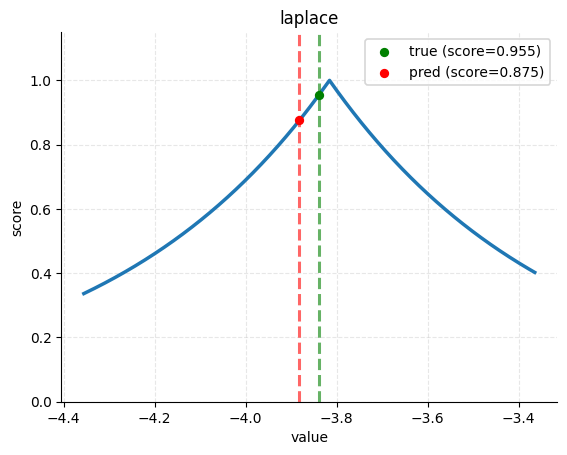

{'pdf_type': 'laplace',
 'true_target': -3.8383246197514502,
 'prediction': -3.8817392328154474,
 'score_true': 0.9554859123626188,
 'score_pred': 0.8753060130523944,
 'x_range': (-4.355369791382356, -3.364694061184542)}

In [10]:
plot_pdf_with_true_target(best["pdf_type"],best["pdf_args"],torque_margin_true,np.mean(tree_preds["trq_margin_pred"]))

In [5]:
predict_test=rf_model.predict_mean_all(test_df,test_df["trq_margin"],FEATURES,keep_cols=["mgt","ias","oat","np_ng_ratio","pa","faulty"])

In [8]:
predict_test.to_csv(OUTPUT_PATH+"pred_margin_test.csv")

In [17]:
r = permutation_importance(
    rf_model.model,
    X_test,
    y_test,
    n_repeats=10,
    random_state=42,
    n_jobs=-1
)

perm_imp = pd.Series(r.importances_mean, index=FEATURES)\
             .sort_values(ascending=False)

print(perm_imp.head(10))

/Users/alessandropettinaro/PycharmProjects/PHM_2024_Project/.venv/lib/python3.11/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


mgt             0.507832
oat             0.301525
trq_measured    0.161045
np_ng_ratio     0.033680
pa              0.006045
ias             0.004013
dtype: float64


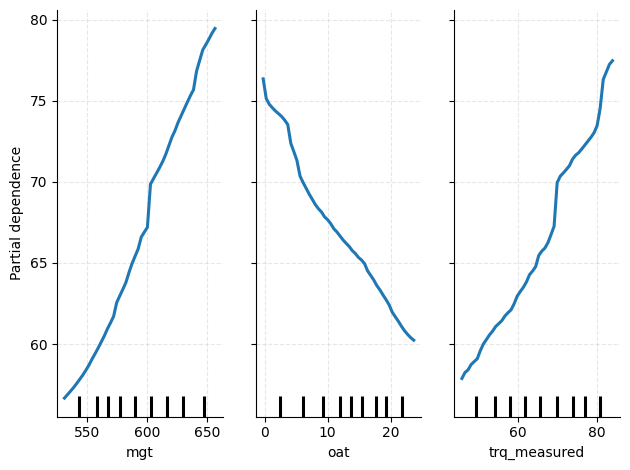

In [18]:
X_test_df = pd.DataFrame(X_test, columns=FEATURES)
top_main = ["mgt", "oat", "trq_measured"]

PartialDependenceDisplay.from_estimator(
    rf_model.model if hasattr(rf_model, "model") else rf_model,
    X_test_df,
    features=top_main,
    grid_resolution=50
)

plt.tight_layout()
plt.show()

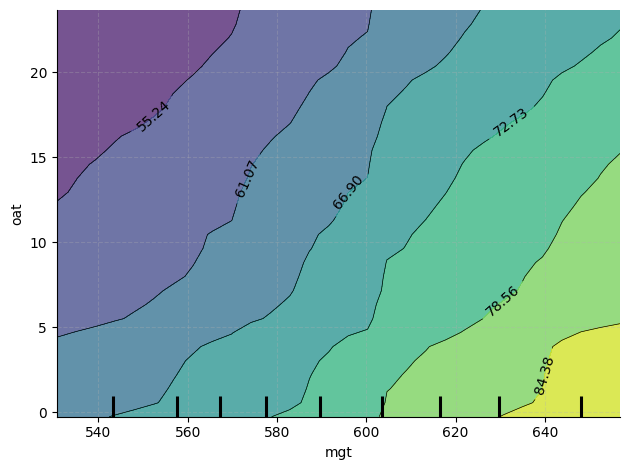

In [19]:
PartialDependenceDisplay.from_estimator(
    rf_model.model if hasattr(rf_model, "model") else rf_model,
    X_test_df,
    features=[("mgt", "oat")],
    grid_resolution=30
)

plt.tight_layout()
plt.show()

In [ ]:
import shap

X_test_df = pd.DataFrame(X_test, columns=FEATURES)


model = rf_model.model if hasattr(rf_model, "model") else rf_model

explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test_df)
shap.summary_plot(shap_values, X_test_df)